In [ ]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt

CONV_DIR = '../examples/comparisons/closed_boundary_DIIID/convergence'
METHOD = 'Bayesian'
N_COILS = 3

In [16]:
data = {}
for cfg in sorted(os.listdir(CONV_DIR)):
    m = re.match(r'lambda:([^,]+),coils:(\d+)', cfg)
    if not m:
        continue
    lam, coils = float(m.group(1)), int(m.group(2))
    if coils != N_COILS:
        continue
    cfg_dir = os.path.join(CONV_DIR, cfg)
    total_currents, flux_errs = [], []
    for run in sorted(os.listdir(cfg_dir)):
        rpath = os.path.join(cfg_dir, run, 'results.json')
        if not os.path.exists(rpath):
            continue
        d = json.load(open(rpath))
        if METHOD not in d['methods']:
            continue
        res = d['methods'][METHOD]
        total_currents.append(np.sum(np.abs(res['coil_currents'])))
        flux_errs.append(res['best_flux_err'])
    if total_currents:
        data[lam] = {'total_current': np.mean(total_currents), 'flux_err': np.mean(flux_errs)}

lambdas = sorted(data.keys())
currents = [data[l]['total_current'] for l in lambdas]
flux_errs = [data[l]['flux_err'] for l in lambdas]
print(f'configs found: {len(lambdas)}')
for l, c, f in zip(lambdas, currents, flux_errs):
    print(f'lambda={l:.0e} total_current={c:.3e} flux_err={f:.3e}')

configs found: 0


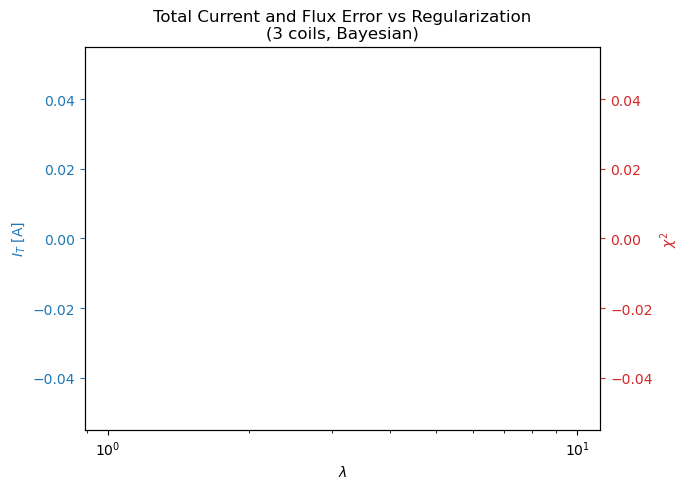

In [17]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

ax1.plot(lambdas, currents, 'o-', color='tab:blue')
ax2.plot(lambdas, flux_errs, 's--', color='tab:red')

ax1.set_xscale('log')
ax1.set_xlabel(r'$\lambda$')
ax1.set_ylabel(r'$I_T$ [A]', color='tab:blue')
ax2.set_ylabel(r'$\chi^2$', color='tab:red')
ax1.tick_params(axis='y', colors='tab:blue')
ax2.tick_params(axis='y', colors='tab:red')
ax1.set_title(f'Total Current and Flux Error vs Regularization\n({N_COILS} coils, {METHOD})')
plt.tight_layout()
plt.show()